# **Exploratory Data Analysis**
---


## **(1) Starting Dataset**

### **(1.1) Summary of the Dataset**

In [134]:
import sys
import os
import pandas as pd

pd.set_option('display.max_rows', None)

sys.path.append(os.path.abspath('..'))

from src.dataset import returnDataset

df = returnDataset('../data/d2assignment_dataset.csv')
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96112 entries, 0 to 96111
Data columns (total 54 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   row_id               96112 non-null  int64  
 1   delinq_24m           96112 non-null  float64
 2   total_tradelines     96112 non-null  float64
 3   oldest_revolving_m   96112 non-null  float64
 4   install_limit_total  96112 non-null  float64
 5   card_limit_total     96112 non-null  float64
 6   card_headroom        95159 non-null  float64
 7   emp_years            90130 non-null  float64
 8   pct_clean_history    96112 non-null  float64
 9   principal_req        96112 non-null  float64
 10  income_verif         96112 non-null  int64  
 11  card_util            95076 non-null  float64
 12  income_annual        96112 non-null  float64
 13  total_balance        96112 non-null  float64
 14  bankruptcies         96112 non-null  float64
 15  late_fees            96112 non-null 

,row_id,delinq_24m,total_tradelines,oldest_revolving_m,install_limit_total,card_limit_total,card_headroom,emp_years,pct_clean_history,principal_req,...,payments_total,active_cards,revolving_bal,mortgage_ct,risk_band,debt_ratio,pct_cards_hi_util,housing_status,review_gap_m,target
count,96112.000000,96112.000000,96112.000000,96112.000000,9.611200e+04,96112.000000,95159.000000,90130.000000,96112.000000,96112.000000,...,96112.000000,96112.000000,9.611200e+04,96112.000000,96112.000000,96112.000000,95079.000000,96112.000000,96108.000000,96112.000000
mean,60018.819232,0.353785,24.958840,182.821895,4.159092e+04,17535.665682,11343.913135,5.896583,93.778882,17654.144238,...,12890.229274,3.630879,2.245203e+04,1.620734,2.448404,37.208776,47.527449,1.026677,40.498262,0.143551
std,34671.558271,0.953711,11.969178,95.737204,4.420776e+04,18393.931438,18020.111385,3.697968,8.965285,10843.944157,...,8607.232525,2.187661,3.248592e+04,2.037825,1.151733,15.909035,35.675679,0.944736,12.374455,0.350636
min,0.000000,0.000000,2.000000,6.000000,0.000000e+00,0.000000,0.000000,0.000000,17.800000,1562.000000,...,0.000000,0.000000,0.000000e+00,0.000000,1.000000,2.820000,0.000000,0.000000,0.000000,0.000000
25%,29988.750000,0.000000,16.000000,115.000000,1.340500e+04,5897.000000,1526.000000,2.000000,90.700000,9718.000000,...,6467.000000,2.000000,8.231000e+03,0.000000,2.000000,25.140000,16.500000,0.000000,34.000000,0.000000
50%,60010.500000,0.000000,23.000000,165.000000,3.087500e+04,11699.000000,4878.000000,6.000000,97.300000,14099.000000,...,10662.000000,3.000000,1.510450e+04,1.000000,2.000000,36.120000,49.700000,1.000000,43.000000,0.000000
75%,90077.250000,0.000000,32.000000,232.000000,5.594725e+04,22472.000000,13235.500000,10.000000,100.000000,23217.500000,...,17119.000000,5.000000,2.693550e+04,3.000000,3.000000,48.380000,75.300000,2.000000,49.000000,0.000000
max,119999.000000,21.000000,169.000000,851.000000,1.121864e+06,392898.000000,346750.000000,10.000000,101.600000,49719.000000,...,48606.000000,26.000000,3.670889e+06,31.000000,7.000000,79.330000,101.700000,2.000000,63.000000,1.000000


### **(1.2) Missing Values**

In [135]:
missing_values_df = pd.DataFrame({
    'missing_values_count': df.isna().sum(),
    'missing_values_perc': (df.isna().mean() * 100).round(2)
}).reset_index().rename(columns={'index': 'column'})

print(missing_values_df)

                 column  missing_values_count  missing_values_perc
0                row_id                     0                 0.00
1            delinq_24m                     0                 0.00
2      total_tradelines                     0                 0.00
3    oldest_revolving_m                     0                 0.00
4   install_limit_total                     0                 0.00
5      card_limit_total                     0                 0.00
6         card_headroom                   953                 0.99
7             emp_years                  5982                 6.22
8     pct_clean_history                     0                 0.00
9         principal_req                     0                 0.00
10         income_verif                     0                 0.00
11            card_util                  1036                 1.08
12        income_annual                     0                 0.00
13        total_balance                     0                 

### **(1.3) Correlation Analysis**

target                 1.000000
residual_amt           0.505865
fee_adj                0.495057
account_flag           0.323913
pricing_rate           0.204632
risk_band              0.204063
late_fees              0.111342
new_accts_24m          0.102410
new_accts_12m          0.092207
debt_ratio             0.087271
inquiries_6m           0.066945
pct_cards_hi_util      0.063454
card_util              0.056348
revolving_util         0.040382
bankruptcies           0.026727
active_cards           0.022581
public_records         0.021989
delinq_24m             0.018974
collections_12m        0.014868
open_tradelines        0.013105
region_code            0.008704
monthly_payment       -0.000321
area_code             -0.007461
row_id                -0.007987
m_since_delinq        -0.008937
pct_clean_history     -0.013022
total_tradelines      -0.014265
install_limit_total   -0.018052
principal_req         -0.019426
emp_years             -0.019898
income_verif          -0.020059
balance_

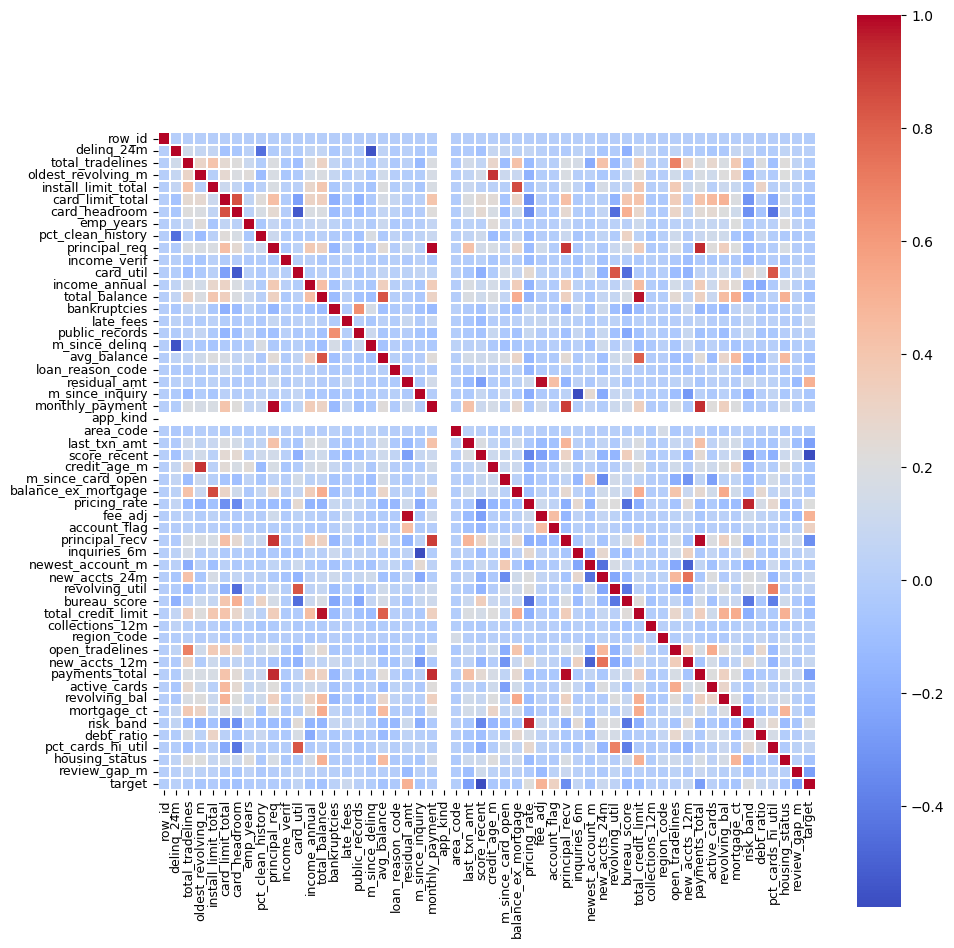

In [136]:
# Feature Correlation with the Target
correlations = df.corr()
print(correlations['target'].sort_values(ascending=False))

# Correlation Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
sns.heatmap(
      correlations,
      cmap='coolwarm',
      fmt='.2f',
      linewidths=.1,
      xticklabels=correlations.columns,
      yticklabels=correlations.columns,
      square=True
)

plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [137]:
from src.feature_engineering import feature_engineering

df_eng = feature_engineering(df)

df_eng.info()
df_eng.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96112 entries, 0 to 96111
Data columns (total 68 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   row_id                     96112 non-null  int64  
 1   delinq_24m                 96112 non-null  float64
 2   total_tradelines           96112 non-null  float64
 3   oldest_revolving_m         96112 non-null  float64
 4   install_limit_total        96112 non-null  float64
 5   card_limit_total           96112 non-null  float64
 6   card_headroom              95159 non-null  float64
 7   emp_years                  90130 non-null  float64
 8   pct_clean_history          96112 non-null  float64
 9   principal_req              96112 non-null  float64
 10  income_verif               96112 non-null  int64  
 11  card_util                  95076 non-null  float64
 12  income_annual              96112 non-null  float64
 13  total_balance              96112 non-null  flo

,row_id,delinq_24m,total_tradelines,oldest_revolving_m,install_limit_total,card_limit_total,card_headroom,emp_years,pct_clean_history,principal_req,...,util_gap,headroom_to_income,limit_saturation,non_mortgage_loans,inquiry_intensity,inquiry_acceleration,acct_velocity_ratio,delinq_per_tradeline,total_derogatory_events,dirty_tradelines
count,96112.000000,96112.000000,96112.000000,96112.000000,9.611200e+04,96112.000000,95159.000000,90130.000000,96112.000000,96112.000000,...,95076.000000,95159.000000,96110.000000,96112.000000,96112.000000,86257.000000,96112.000000,96112.000000,96112.000000,96112.000000
mean,60018.819232,0.353785,24.958840,182.821895,4.159092e+04,17535.665682,11343.913135,5.896583,93.778882,17654.144238,...,8.145999,0.206433,0.793439,1.180026,0.225623,14708.675952,0.089628,1.075517,0.404975,-2315.024452
std,34671.558271,0.953711,11.969178,95.737204,4.420776e+04,18393.931438,18020.111385,3.697968,8.965285,10843.944157,...,14.122089,0.322673,0.219086,0.674213,0.382967,58521.708381,0.079848,322.560410,0.941009,1144.720587
min,0.000000,0.000000,2.000000,6.000000,0.000000e+00,0.000000,0.000000,0.000000,17.800000,1562.000000,...,-92.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-15869.100000
25%,29988.750000,0.000000,16.000000,115.000000,1.340500e+04,5897.000000,1526.000000,2.000000,90.700000,9718.000000,...,0.200000,0.029655,0.659136,0.417795,0.000000,0.000000,0.035714,0.000000,0.000000,-2963.600000
50%,60010.500000,0.000000,23.000000,165.000000,3.087500e+04,11699.000000,4878.000000,6.000000,97.300000,14099.000000,...,5.000000,0.095297,0.839359,1.672934,0.000000,0.000000,0.074074,0.000000,0.000000,-2155.200000
75%,90077.250000,0.000000,32.000000,232.000000,5.594725e+04,22472.000000,13235.500000,10.000000,100.000000,23217.500000,...,14.600000,0.248835,0.959369,1.732684,0.333333,0.499998,0.125000,0.000000,0.000000,-1480.500000
max,119999.000000,21.000000,169.000000,851.000000,1.121864e+06,392898.000000,346750.000000,10.000000,101.600000,49719.000000,...,205.600000,9.568037,2.988405,10.393600,6.000000,600000.000000,0.846154,100000.000000,17.000000,-95.500000


## **(2) Engineered Dataset**

### **(2.1) Summary of the Dataset**

In [138]:
from src.feature_engineering import feature_engineering

df_eng = feature_engineering(df)

df_eng.info()
df_eng.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96112 entries, 0 to 96111
Data columns (total 68 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   row_id                     96112 non-null  int64  
 1   delinq_24m                 96112 non-null  float64
 2   total_tradelines           96112 non-null  float64
 3   oldest_revolving_m         96112 non-null  float64
 4   install_limit_total        96112 non-null  float64
 5   card_limit_total           96112 non-null  float64
 6   card_headroom              95159 non-null  float64
 7   emp_years                  90130 non-null  float64
 8   pct_clean_history          96112 non-null  float64
 9   principal_req              96112 non-null  float64
 10  income_verif               96112 non-null  int64  
 11  card_util                  95076 non-null  float64
 12  income_annual              96112 non-null  float64
 13  total_balance              96112 non-null  flo

,row_id,delinq_24m,total_tradelines,oldest_revolving_m,install_limit_total,card_limit_total,card_headroom,emp_years,pct_clean_history,principal_req,...,util_gap,headroom_to_income,limit_saturation,non_mortgage_loans,inquiry_intensity,inquiry_acceleration,acct_velocity_ratio,delinq_per_tradeline,total_derogatory_events,dirty_tradelines
count,96112.000000,96112.000000,96112.000000,96112.000000,9.611200e+04,96112.000000,95159.000000,90130.000000,96112.000000,96112.000000,...,95076.000000,95159.000000,96110.000000,96112.000000,96112.000000,86257.000000,96112.000000,96112.000000,96112.000000,96112.000000
mean,60018.819232,0.353785,24.958840,182.821895,4.159092e+04,17535.665682,11343.913135,5.896583,93.778882,17654.144238,...,8.145999,0.206433,0.793439,1.180026,0.225623,14708.675952,0.089628,1.075517,0.404975,-2315.024452
std,34671.558271,0.953711,11.969178,95.737204,4.420776e+04,18393.931438,18020.111385,3.697968,8.965285,10843.944157,...,14.122089,0.322673,0.219086,0.674213,0.382967,58521.708381,0.079848,322.560410,0.941009,1144.720587
min,0.000000,0.000000,2.000000,6.000000,0.000000e+00,0.000000,0.000000,0.000000,17.800000,1562.000000,...,-92.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-15869.100000
25%,29988.750000,0.000000,16.000000,115.000000,1.340500e+04,5897.000000,1526.000000,2.000000,90.700000,9718.000000,...,0.200000,0.029655,0.659136,0.417795,0.000000,0.000000,0.035714,0.000000,0.000000,-2963.600000
50%,60010.500000,0.000000,23.000000,165.000000,3.087500e+04,11699.000000,4878.000000,6.000000,97.300000,14099.000000,...,5.000000,0.095297,0.839359,1.672934,0.000000,0.000000,0.074074,0.000000,0.000000,-2155.200000
75%,90077.250000,0.000000,32.000000,232.000000,5.594725e+04,22472.000000,13235.500000,10.000000,100.000000,23217.500000,...,14.600000,0.248835,0.959369,1.732684,0.333333,0.499998,0.125000,0.000000,0.000000,-1480.500000
max,119999.000000,21.000000,169.000000,851.000000,1.121864e+06,392898.000000,346750.000000,10.000000,101.600000,49719.000000,...,205.600000,9.568037,2.988405,10.393600,6.000000,600000.000000,0.846154,100000.000000,17.000000,-95.500000


### **(2.2) Missing Values**
Missing values will be imputed in the models pipeline.

In [139]:
missing_values_df_eng = pd.DataFrame({
    'missing_values_count': df_eng.isna().sum(),
    'missing_values_perc': (df_eng.isna().mean() * 100).round(2)
}).reset_index().rename(columns={'index': 'column'})

print(missing_values_df_eng)

                       column  missing_values_count  missing_values_perc
0                      row_id                     0                 0.00
1                  delinq_24m                     0                 0.00
2            total_tradelines                     0                 0.00
3          oldest_revolving_m                     0                 0.00
4         install_limit_total                     0                 0.00
5            card_limit_total                     0                 0.00
6               card_headroom                   953                 0.99
7                   emp_years                  5982                 6.22
8           pct_clean_history                     0                 0.00
9               principal_req                     0                 0.00
10               income_verif                     0                 0.00
11                  card_util                  1036                 1.08
12              income_annual                     0

### **(2.3) Data Pre-Processing**
Remove leakage features, impute missing values, remove unnecessary columns.

In [140]:
# Leakage Features
LEAKAGE_COLS = [
      'principal_recv',
      'payments_total',
      'last_txn_amt',
      'late_fees',
      'residual_amt',
      'fee_adj',
      'review_gap_m',
      'account_flag',
      'score_recent'
]

# Metadata Features
METADATA_COLS = [
      'row_id',
      'app_kind'
]

# Other Features to Drop
DROP_COLS = [
      'region_code',
      'area_code'
]

df_eng = df_eng.drop([*LEAKAGE_COLS, *METADATA_COLS, *DROP_COLS], axis=1)

### **(2.4) Correlation Analysis**

In [141]:
# Feature Correlation with the Target
correlations_eng = df_eng.corr()
print(correlations_eng['target'].sort_values(ascending=False))

target                       1.000000
pricing_rate                 0.204632
risk_band                    0.204063
new_accts_24m                0.102410
acct_velocity_ratio          0.101043
new_accts_12m                0.092207
monthly_payment_on_income    0.090314
debt_ratio                   0.087271
non_mortgage_loans           0.078255
loan_income_ratio            0.070223
inquiries_6m                 0.066945
pct_cards_hi_util            0.063454
card_util                    0.056348
revolving_util               0.040382
util_gap                     0.039083
inquiry_intensity            0.031788
total_derogatory_events      0.028083
bankruptcies                 0.026727
active_cards                 0.022581
public_records               0.021989
delinq_24m                   0.018974
inquiry_acceleration         0.018916
dirty_tradelines             0.017964
free_cash_flow               0.015608
collections_12m              0.014868
open_tradelines              0.013105
delinq_per_t

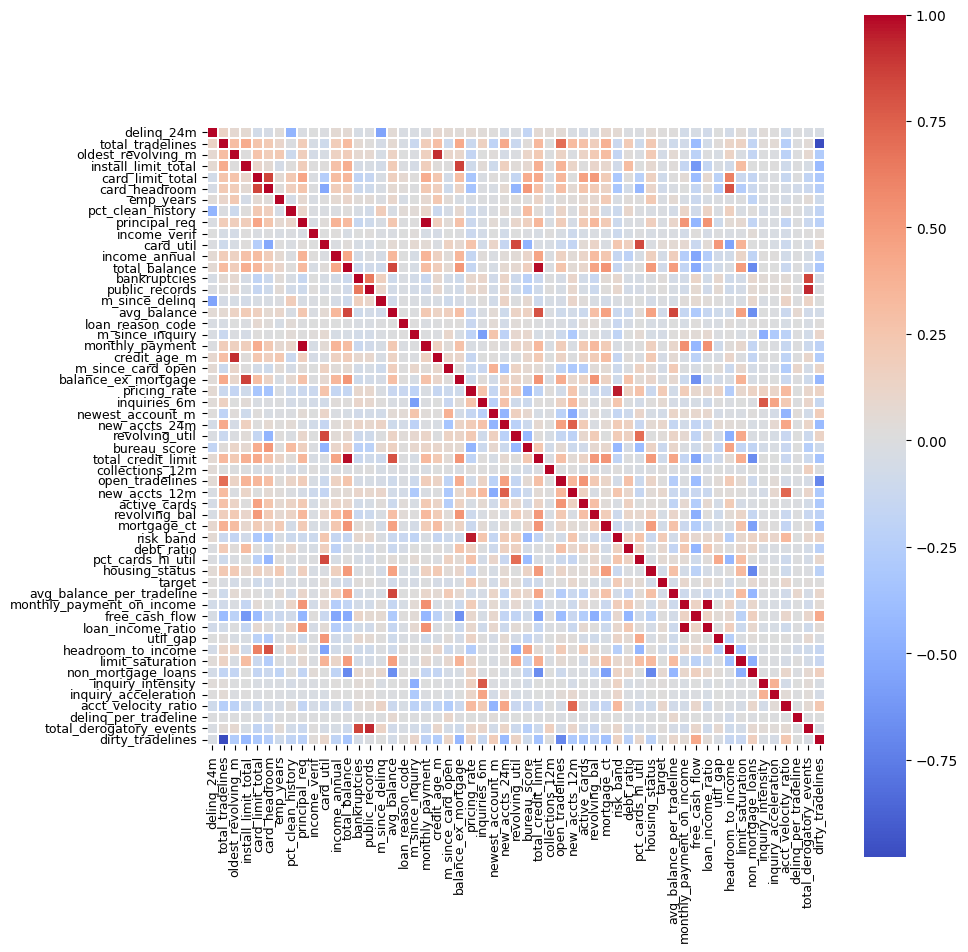

In [142]:
# Correlation Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
sns.heatmap(
      correlations_eng,
      cmap='coolwarm',
      fmt='.2f',
      linewidths=.1,
      xticklabels=correlations_eng.columns,
      yticklabels=correlations_eng.columns,
      square=True
)

plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()